#### THIS EXAMPLE IS AN EXPERIMENT ON HOW TO COMBINE CORRELATIONS ETC. WITH STATISTICAL SIGNIFICANCE VALUES (p-value)

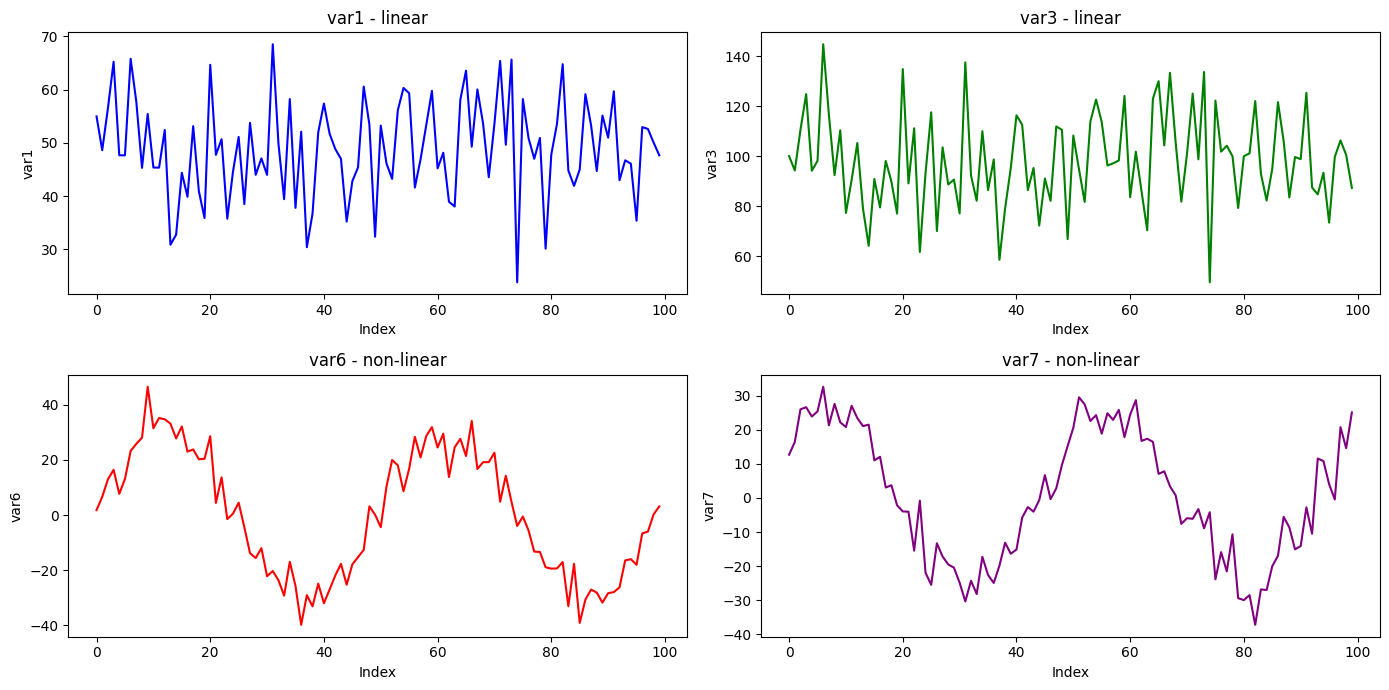

In [1]:
# most of this code is just experimentation with ChatGPT 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Set seed for reproducibility
np.random.seed(42)
size = 100

# --- Linear Trends ---
# Linear trend with noise
var1 = np.random.normal(loc=50, scale=10, size=size)  # Base variable

# Linear trend with noise, similar to var1 and var2, but slightly different
noise2 = np.random.normal(loc=0, scale=7, size=size)  # More noise for slight difference
var3 = var1 * 2 + noise2  # Similar to var2, but more noisy

# --- Non-linear Trends ---
x = np.linspace(0, 4 * np.pi, size)

# Non-linear relationship (sine wave + noise)
var6 = np.sin(x) * 30 + np.random.normal(loc=0, scale=5, size=size)

# Another non-linear relationship (scaled and phase-shifted sine wave + noise)
# Making var7 similar but with a scaling factor and phase shift
var7 = np.sin(x + np.pi / 4) * 25 + np.random.normal(loc=0, scale=6, size=size)

# Create DataFrame
df = pd.DataFrame({
    'var1': var1,
    'var3': var3,
    'var6': var6,
    'var7': var7
})

# Create line plots for each variable
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Line plot for var1 (Linear)
axes[0, 0].plot(df.index, df['var1'], color='blue', label='var1')
axes[0, 0].set_title('var1 - linear')
axes[0, 0].set_xlabel('Index')
axes[0, 0].set_ylabel('var1')

# Line plot for var2 (Linear, similar to var1)
axes[0, 1].plot(df.index, df['var3'], color='green', label='var3')
axes[0, 1].set_title('var3 - linear')
axes[0, 1].set_xlabel('Index')
axes[0, 1].set_ylabel('var3')

# Line plot for var3 (Linear, slightly more noise)
axes[1, 0].plot(df.index, df['var6'], color='red', label='var6')
axes[1, 0].set_title('var6 - non-linear')
axes[1, 0].set_xlabel('Index')
axes[1, 0].set_ylabel('var6')

# Line plot for var4 (Monotonic with fluctuation)
axes[1, 1].plot(df.index, df['var7'], color='purple', label='var7')
axes[1, 1].set_title('var7 - non-linear')
axes[1, 1].set_xlabel('Index')
axes[1, 1].set_ylabel('var7')


# Adjust layout and remove empty subplot space
fig.tight_layout()
plt.show()


In [2]:
# Function to calculate correlation and p-value matrices (Pearson)
def corr_with_pvalues_pearson(df):
    # Initialize matrices
    corr_matrix = df.corr()
    pval_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)

    # Calculate p-values
    for col1 in df.columns:
        for col2 in df.columns:
            if col1 == col2:
                pval_matrix.loc[col1, col2] = 0.0
            else:
                _, pval = pearsonr(df[col1], df[col2])
                pval_matrix.loc[col1, col2] = pval

    # Format p-values for readability
    pval_matrix = pval_matrix.map(lambda p: f"{p:.4f}")
    
    return corr_matrix, pval_matrix


# Call the function and get Pearson correlation + p-value matrices
pearson_corr_matrix, pearson_pval_matrix = corr_with_pvalues_pearson(df)


# Display Pearson correlation matrix and p-values
print("Pearson Correlation Matrix:")
print(pearson_corr_matrix)
print("\nPearson P-Value Matrix:")
print(pearson_pval_matrix)

# var1 and var 3 are HEAVILY CORRELATED
# p-value = 0.0 => statistically significant
# can also imply redundancy!

# when using pearsonr => p-value is calculated by using T-TEST

Pearson Correlation Matrix:
          var1      var3      var6      var7
var1  1.000000  0.933751  0.092846  0.029335
var3  0.933751  1.000000  0.135571  0.030554
var6  0.092846  0.135571  1.000000  0.713922
var7  0.029335  0.030554  0.713922  1.000000

Pearson P-Value Matrix:
        var1    var3    var6    var7
var1  0.0000  0.0000  0.3582  0.7720
var3  0.0000  0.0000  0.1787  0.7628
var6  0.3582  0.1787  0.0000  0.0000
var7  0.7720  0.7628  0.0000  0.0000


In [3]:
# pip install phik
import phik
from phik import phik_matrix

phik_matrix_df = df.phik_matrix()

# We can't compute significance for Phik using a direct function like Pearson, so we'll use a permutation-based test
# Here, we'll use a basic placeholder for statistical significance (not implemented in phik directly)
def compute_stat_significance(df):
    n = len(df)
    significance_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)

    # For each pair of columns, we'll compute p-value using permutation testing
    for col1 in df.columns:
        for col2 in df.columns:
            if col1 == col2:
                significance_matrix.loc[col1, col2] = 0.0
            else:
                # Permutation-based testing (placeholder)
                _, p_val = pearsonr(df[col1], df[col2])
                significance_matrix.loc[col1, col2] = p_val
    return significance_matrix

# Generate significance matrix
significance_matrix = compute_stat_significance(df)
significance_matrix = significance_matrix.map(lambda p: f"{p:.4f}")

print("Phik-matrix:")
print(phik_matrix_df)
print("\nPhik, P-value matrix:")
print(significance_matrix)

# if p-value rises too high while correlation/association is high
# this means the connection is probably coincidental or just a "fluke"
# this can be due to lots of noise in data or the sample size (more common reason) is too small

# So even if large datasets, the subsets of data that cause the correlation/association 
# can be so rare, that the p-value starts to rise 

# "the variables seem to be connected, but only a minority of data shows this connection"?

# in other words, high p-value implies we don't have enough data to be certain of the connection (sample size)
# high p-value => uncertainty of the "prediction"
# low p-value implies high certainty in the detected trend

# We use correlation/Phikₖ to detect potential relationships, 
# and p-values to evaluate whether the dataset provides enough evidence to trust those relationships.

# high correlation/phik-value + high p-value, some definitions:
# “There appears to be a dependency pattern, but we cannot rule out that it arose by chance.”
# “The data suggests a dependency pattern, but there isn’t enough statistical evidence to conclude it exists in the population.”#
# “There may be a relationship, but the data doesn’t provide enough reliable evidence to trust it yet.”

# Strong effect (high correlation/phik) + strong evidence (low p-value) → relationship that might be real and reliable

# all in all, combining p-value with correlation and phik-matrix is useful, but it's not a silver bullet
# it might imply a strong, meaningful and reliable connection, but you need other analytics methods to ensure that

# Effectively when we combine correlations/associations with p-value (statistical significance),
# we can quite quickly analyse if our data is large enough but also VERSATILE enough to 
# have significant presence for each micro-trend also in the data

# in pearson, p-value is based on t-test
# in phik, p-value is based on chi-squared

# Method	Measures	            Assumes	Significance        test used
# -------------------------------------------------------------------------------
# Pearson	Linear correlation	    Continuous + normality	    t-test
# Phik	    Any association	        Categorical / binned	    Chi-squared test

# heavy association between var6 and var7
# and also statistically significant (or redundant)

# “Statistical significance tells you a relationship is likely real—not that it’s useful in machine learning.”

interval columns not set, guessing: ['var1', 'var3', 'var6', 'var7']
Phik-matrix:
          var1      var3      var6      var7
var1  1.000000  0.908341  0.000000  0.554542
var3  0.908341  1.000000  0.201971  0.247373
var6  0.000000  0.201971  1.000000  0.608097
var7  0.554542  0.247373  0.608097  1.000000

Phik, P-value matrix:
        var1    var3    var6    var7
var1  0.0000  0.0000  0.3582  0.7720
var3  0.0000  0.0000  0.1787  0.7628
var6  0.3582  0.1787  0.0000  0.0000
var7  0.7720  0.7628  0.0000  0.0000
